In [ ]:
from pathlib import Path

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import wandb
import xarray as xr
from context_flux_no.training.io import load_model
from jaxtyping import Array, Float
from matplotlib.animation import ArtistAnimation


datadir = Path("../../data")
checkpoint_dir = Path("../../checkpoints")

jax.config.update("jax_default_device", jax.devices("gpu")[3])

## Query wandb API and obtain loss curves

In [169]:
api = wandb.Api()
run_dpot = api.run("jhko725/hyperfluxfno/cgwa58nd")
run_hyperfluxfno = api.run("jhko725/hyperfluxfno/nni87so3")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.


<IPython.core.display.Javascript object>

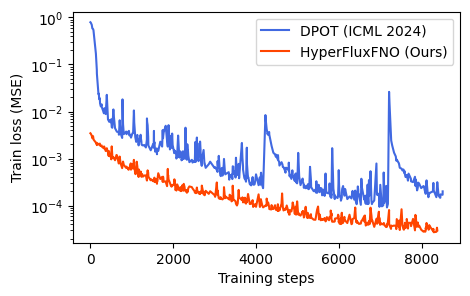

In [184]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(
    *run_dpot.history(keys=["train_loss"]).to_numpy().T,
    label="DPOT (ICML 2024)",
    color="royalblue",
)
ax.plot(
    *run_hyperfluxfno.history(keys=["train_loss"]).to_numpy().T,
    label="HyperFluxFNO (Ours)",
    color="orangered",
)
ax.set_yscale("log", base=10)
ax.set_ylabel("Train loss (MSE)")
ax.set_xlabel("Training steps")
ax.legend()
fig

## Load trained models and dataset

In [46]:
dpot = load_model(checkpoint_dir / "DPOT/26-03-11-23:47:50")
hyperfluxfno = load_model(checkpoint_dir / "HyperFluxFNO/26-03-11-23:47:19")

In [24]:
dataset_train = xr.open_dataset(
    datadir / "cubic_no_source_large_train.hdf5", engine="h5netcdf", chunks={}
)
dataset_train_extrap = dataset_train.isel({"t": slice(61, None)})

In [25]:
batch_extrap = dataset_train_extrap["values"].isel({"ic": 0}).compute().to_numpy()

In [30]:
batch_extrap[:, 20:].shape

(1000, 20, 1, 100)

## Generate model predictions and visualize

In [53]:
dpot = eqx.nn.inference_mode(dpot, True)
batch_extrap_pred_dpot = eqx.filter_vmap(
    lambda u: dpot.rollout(u, args=None, num_steps=20)
)(batch_extrap[:, :20])[0]

In [55]:
dt = float(dataset_train_extrap["t"][1] - dataset_train_extrap["t"][0])
dx = float(dataset_train_extrap["x"][1] - dataset_train_extrap["x"][0])

hyperfluxfno = eqx.nn.inference_mode(hyperfluxfno, True)
batch_extrap_pred_hyperfluxfno = eqx.filter_vmap(
    lambda u: hyperfluxfno.rollout(
        u, args=(dt, dx), num_steps=20, key=jax.random.key(0)
    )
)(batch_extrap[:, :20])[0]

In [49]:
batch_extrap_pred_hyperfluxfno[0].shape

(1000, 20, 1, 100)

<IPython.core.display.Javascript object>

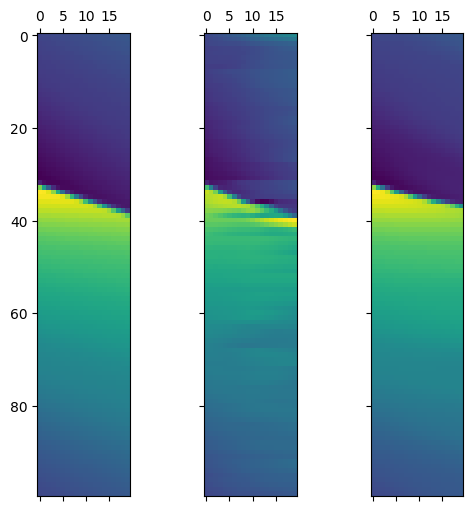

In [162]:
sample_idx = 5
fig, axes = plt.subplots(
    1, 3, figsize=(5, 5), constrained_layout=True, sharex=True, sharey=True
)
axes[0].matshow(batch_extrap[sample_idx, 20:, 0].T)
axes[1].matshow(batch_extrap_pred_dpot[sample_idx, :, 0].T)
axes[2].matshow(batch_extrap_pred_hyperfluxfno[sample_idx, :, 0].T)
fig

In [ ]:
plt.rcParams["animation.html"] = "jshtml"
fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True, constrained_layout=True)


def make_frame(timestep: int):
    if timestep == 0:
        plot_kwargs = {"animated": False}
        axes[-1].set_xlabel("$x$")
        axes[0].set_ylabel("$u$")
        axes[1].set_ylabel("$u_{pred}-u_{data}$")
    else:
        plot_kwargs = {"animated": True}

    plot1 = axes[0].plot(
        batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="Data",
        linewidth=2.0,
        color="black",
        alpha=0.9,
        **plot_kwargs,
    )[0]
    plot2 = axes[0].plot(
        batch_extrap_pred_dpot[sample_idx, timestep, 0].T,
        label="DPOT (ICML 2024)",
        alpha=0.8,
        linewidth=1.5,
        color="royalblue",
        **plot_kwargs,
    )[0]
    plot3 = axes[0].plot(
        batch_extrap_pred_hyperfluxfno[sample_idx, timestep, 0].T,
        label="HyperFluxFNO (Ours)",
        alpha=0.9,
        linewidth=1.5,
        color="orangered",
        **plot_kwargs,
    )[0]
    plot4 = axes[1].plot(
        batch_extrap_pred_dpot[sample_idx, timestep, 0].T
        - batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="DPOT (ICML 2024)",
        alpha=0.8,
        linewidth=1.5,
        color="royalblue",
        **plot_kwargs,
    )[0]
    plot5 = axes[1].plot(
        batch_extrap_pred_hyperfluxfno[sample_idx, timestep, 0].T
        - batch_extrap[sample_idx, 20 + timestep, 0].T,
        label="HyperFluxFNO (Ours)",
        alpha=0.8,
        linewidth=1.5,
        color="orangered",
        **plot_kwargs,
    )[0]
    text_y = (
        jnp.max(batch_extrap[sample_idx, :, 0]) * 0.8
        + jnp.min(batch_extrap[sample_idx, :, 0]) * 0.2
    )
    text0 = axes[0].text(70, text_y, f"$t=0.4+{dt * timestep:.3f}$", fontsize="large")
    if timestep == 0:
        fig.legend(*axes[0].get_legend_handles_labels(), loc="outside center right")
    axes[0].set_title(f"Extrapolation for (pde, ic)={(sample_idx, 0)}")
    return (plot1, plot2, plot3, plot4, plot5, text0)


frames = [make_frame(i) for i in range(20)]


ani = ArtistAnimation(fig, frames, interval=50, blit=True)
ani.save(f"../../figures/cubic_extrapolation_{sample_idx}_0.gif")
ani

<IPython.core.display.Javascript object>

## Compute rel. RMSE as a function of rollout

In [ ]:
def relative_rmse(
    u_pred: Float[Array, "channels ..."], u_data: Float[Array, "channels ..."]
):
    return jnp.sqrt(jnp.mean((u_pred - u_data) ** 2)) / jnp.sqrt(jnp.mean(u_data**2))

In [103]:
rel_rmse_dpot = jnp.mean(
    jax.vmap(jax.vmap(relative_rmse))(batch_extrap[:, 20:], batch_extrap_pred_dpot),
    axis=0,
)
rel_rmse_hyperfluxfno = jnp.mean(
    jax.vmap(jax.vmap(relative_rmse))(
        batch_extrap[:, 20:], batch_extrap_pred_hyperfluxfno
    ),
    axis=0,
)

<IPython.core.display.Javascript object>

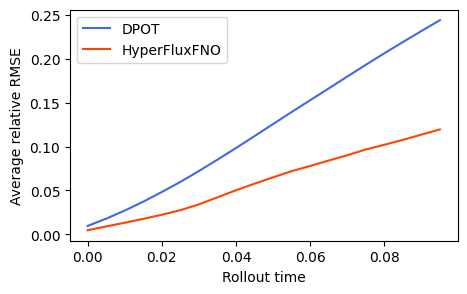

In [128]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(
    jnp.arange(len(rel_rmse_dpot)) * dt, rel_rmse_dpot, label="DPOT", color="royalblue"
)
ax.plot(
    jnp.arange(len(rel_rmse_hyperfluxfno)) * dt,
    rel_rmse_hyperfluxfno,
    label="HyperFluxFNO",
    color="orangered",
)
ax.set_ylabel("Average relative RMSE")
ax.set_xlabel("Rollout time")
ax.legend()
fig